In [1]:
# Install the CUDA 12.4 enabled versions
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124


In [2]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available? {'✅ Yes!' if torch.cuda.is_available() else '❌ No'}")

if torch.cuda.is_available():
    print(f"Current Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Capability: {torch.cuda.get_device_capability(0)}")
else:
    print("PyTorch is using your CPU. We might need a CUDA-specific install if you want it faster.")

PyTorch version: 2.6.0+cu124
Is CUDA available? ✅ Yes!
Current Device: NVIDIA GeForce RTX 3070 Laptop GPU
CUDA Capability: (8, 6)


In [3]:
conda env list


# conda environments:
#
# * -> active
# + -> frozen
base                 *   C:\Users\Admin\anaconda3
gpu_support              C:\Users\Admin\anaconda3\envs\gpu_support


Note: you may need to restart the kernel to use updated packages.


In [4]:
import os

# Define the source folder where Kaggle extracted the data
source_dir = 'MSRA10K_Imgs_GT/imgs' 

# [REQUIREMENT]: Download and inspect the dataset
all_files = os.listdir(source_dir)
images = [f for f in all_files if f.endswith('.jpg')]
masks = [f for f in all_files if f.endswith('.png')]

print(f"Total Images (.jpg): {len(images)}")
print(f"Total Masks (.png): {len(masks)}")

if len(images) == len(masks) and len(images) > 0:
    print("✅ Success: Dataset inspected and counts match.")

Total Images (.jpg): 10000
Total Masks (.png): 10000
✅ Success: Dataset inspected and counts match.


In [5]:
import shutil
import random

# 1. Define the folder structure
base_path = 'data'
splits = ['train', 'val', 'test']
subfolders = ['images', 'masks']

for split in splits:
    for sub in subfolders:
        os.makedirs(os.path.join(base_path, split, sub), exist_ok=True)

# 2. Prepare file names and shuffle
file_names = [os.path.splitext(f)[0] for f in images]
random.seed(42) 
random.shuffle(file_names)

# [REQUIREMENT]: Split into Train (70%), Validation (15%), and Test (15%)
num_files = len(file_names)
train_end = int(0.70 * num_files)
val_end = int(0.85 * num_files)

split_map = {
    'train': file_names[:train_end],
    'val': file_names[train_end:val_end],
    'test': file_names[val_end:]
}

# 3. Copy files to split folders
for split_name, files in split_map.items():
    for name in files:
        shutil.copy(os.path.join(source_dir, name + '.jpg'), 
                    os.path.join(base_path, split_name, 'images', name + '.jpg'))
        shutil.copy(os.path.join(source_dir, name + '.png'), 
                    os.path.join(base_path, split_name, 'masks', name + '.png'))

print(f"✅ Data organized: Train ({len(split_map['train'])}), Val ({len(split_map['val'])}), Test ({len(split_map['test'])})")

✅ Data organized: Train (7000), Val (1500), Test (1500)


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from PIL import Image

class SODDataset(Dataset):
    def __init__(self, root_dir, split='train', size=(128, 128), augment=False):
        self.img_dir = os.path.join(root_dir, split, 'images')
        self.mask_dir = os.path.join(root_dir, split, 'masks')
        self.file_names = sorted(os.listdir(self.img_dir))
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.file_names)

    def transform(self, image, mask):
        # [REQUIREMENT]: Resize all images to 128x128
        image = TF.resize(image, self.size)
        mask = TF.resize(mask, self.size)

        # [REQUIREMENT]: Implement basic augmentations
        if self.augment:
            # 1. Horizontal flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            
            # 2. Random crop
            if random.random() > 0.5:
                i, j, h, w = T.RandomResizedCrop.get_params(image, scale=(0.8, 1.0), ratio=(1.0, 1.0))
                image = TF.resized_crop(image, i, j, h, w, self.size)
                mask = TF.resized_crop(mask, i, j, h, w, self.size)

            # 3. Brightness variation (Image only)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.8, 1.2))

        # [REQUIREMENT]: Normalize pixel values (0–1 range)
        image = TF.to_tensor(image) # Scales to 0.0 - 1.0
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float() # Threshold mask to be strictly binary

        return image, mask

    def __getitem__(self, idx):
        img_name = self.file_names[idx]
        mask_name = img_name.replace('.jpg', '.png')
        
        image = Image.open(os.path.join(self.img_dir, img_name)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, mask_name)).convert("L")
        
        return self.transform(image, mask)

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from PIL import Image
import os      
import random  

class SODDataset(Dataset):
    def __init__(self, root_dir, split='train', size=(128, 128), augment=False):
        self.img_dir = os.path.join(root_dir, split, 'images')
        self.mask_dir = os.path.join(root_dir, split, 'masks')
        self.file_names = sorted(os.listdir(self.img_dir))
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.file_names)

    def transform(self, image, mask):
        # [REQUIREMENT]: Resize all images to a consistent format (128x128)
        image = TF.resize(image, self.size)
        mask = TF.resize(mask, self.size)

        # [REQUIREMENT]: Implement basic augmentations
        if self.augment:
            # 1. Horizontal flip (Synchronized)
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            
            # 2. Random crop (Synchronized using your get_params logic)
            if random.random() > 0.5:
                i, j, h, w = T.RandomResizedCrop.get_params(image, scale=(0.8, 1.0), ratio=(1.0, 1.0))
                image = TF.resized_crop(image, i, j, h, w, self.size)
                mask = TF.resized_crop(mask, i, j, h, w, self.size)

            # 3. Brightness variation (New: Added to meet your specific requirement)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.8, 1.2))

        # [REQUIREMENT]: Normalize pixel values (0–1 range)
        image = TF.to_tensor(image) # Automatically scales to [0, 1.0]
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float() # Ensures binary mask for SOD

        return image, mask

    def __getitem__(self, idx):
        img_name = self.file_names[idx]
        mask_name = img_name.replace('.jpg', '.png')
        
        # Ensure correct conversion (RGB for image, L/Grayscale for mask)
        image = Image.open(os.path.join(self.img_dir, img_name)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, mask_name)).convert("L")
        
        return self.transform(image, mask)

# Initialize DataLoaders
train_ds = SODDataset('data', split='train', augment=True)
val_ds = SODDataset('data', split='val', augment=False)

# [REQUIREMENT]: Efficient handling using pin_memory
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, pin_memory=True)

print(f"✅ DataLoaders initialized with all requirements (Resize, Normalize, Flip, Crop, Brightness).")

✅ DataLoaders initialized with all requirements (Resize, Normalize, Flip, Crop, Brightness).


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

class SaliencyBaseline(nn.Module):
    def __init__(self):
        super(SaliencyBaseline, self).__init__()
        
        # Input: RGB image (3 x 128 x 128)
        # Encoder: 4 Conv2D layers with ReLU and MaxPooling
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        
        # Decoder: 4 ConvTranspose2D layers with ReLU
        # Output: 1-channel Sigmoid mask
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2), nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SaliencyBaseline().to(device)

def get_iou(pred, target):
    pred_bin = (pred > 0.5).float()
    intersection = (pred_bin * target).sum()
    union = pred_bin.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

# Loss function: Binary Cross-Entropy + 0.5 * (1 - IoU)
def hybrid_loss(pred, target):
    bce = nn.BCELoss()(pred, target)
    iou = get_iou(pred, target)
    return bce + 0.5 * (1 - iou)

# Optimizer: Adam (learning rate = 1e-3)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training setup
epochs = 25
best_val_loss = float('inf')
patience = 3 
no_improvement_count = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = hybrid_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            val_outputs = model(imgs)
            val_loss += hybrid_loss(val_outputs, masks).item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        no_improvement_count = 0
    else:
        no_improvement_count += 1

    # Training epochs: 15-25 (early stop when validation loss stops improving)
    if (epoch + 1) >= 15 and no_improvement_count >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

Epoch [01/25] | Train Loss: 0.8132 | Val Loss: 0.6328
Epoch [02/25] | Train Loss: 0.6479 | Val Loss: 0.6133
Epoch [03/25] | Train Loss: 0.6189 | Val Loss: 0.6159
Epoch [04/25] | Train Loss: 0.6009 | Val Loss: 0.6181
Epoch [05/25] | Train Loss: 0.5779 | Val Loss: 0.5555
Epoch [06/25] | Train Loss: 0.5620 | Val Loss: 0.5389
Epoch [07/25] | Train Loss: 0.5454 | Val Loss: 0.5300
Epoch [08/25] | Train Loss: 0.5389 | Val Loss: 0.5372
Epoch [09/25] | Train Loss: 0.5286 | Val Loss: 0.5157
Epoch [10/25] | Train Loss: 0.5190 | Val Loss: 0.5008
Epoch [11/25] | Train Loss: 0.5097 | Val Loss: 0.5173
Epoch [12/25] | Train Loss: 0.5053 | Val Loss: 0.4931
Epoch [13/25] | Train Loss: 0.4998 | Val Loss: 0.4926
Epoch [14/25] | Train Loss: 0.4946 | Val Loss: 0.4884
Epoch [15/25] | Train Loss: 0.4904 | Val Loss: 0.4894
Epoch [16/25] | Train Loss: 0.4840 | Val Loss: 0.4883
Epoch [17/25] | Train Loss: 0.4826 | Val Loss: 0.4727
Epoch [18/25] | Train Loss: 0.4807 | Val Loss: 0.4684
Epoch [19/25] | Train Loss: 

In [9]:
import os
import torch
from tqdm import tqdm

# ==========================================
# TRAINING CONFIGURATION & RESUME LOGIC
# ==========================================
epochs = 25
start_epoch = 0
best_val_loss = float('inf')
patience = 3 
no_improvement_count = 0
checkpoint_path = 'last_checkpoint.pth'
best_model_path = 'best_sod_model.pth'

# [BONUS REQUIREMENT]: Implement logic to save and resume training progress.
resume_training = False # Set to False to train from scratch

if resume_training and os.path.exists(checkpoint_path):
    print("🔄 Found existing checkpoint. Resuming training...")
    checkpoint = torch.load(checkpoint_path)
    
    # Restore model weights, optimizer memory, and tracking variables
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    
    print(f"✅ Resumed from Epoch {start_epoch} with Best Val Loss: {best_val_loss:.4f}")
else:
    print("🚀 Starting training from scratch...")

# ==========================================
# THE FULL TRAINING LOOP
# ==========================================
for epoch in range(start_epoch, epochs):
    
    # --- 1. TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    
    # [REQUIREMENT]: Added tqdm progress bar for training
    for imgs, masks in tqdm(train_loader, desc=f"Epoch [{epoch+1:02d}/{epochs}] Train"):
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        
        # [REQUIREMENT]: Forward pass
        outputs = model(imgs)
        loss = hybrid_loss(outputs, masks)
        
        # [REQUIREMENT]: Backward pass
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # --- 2. VALIDATION PHASE ---
    # [REQUIREMENT]: Validation after each epoch
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        # [REQUIREMENT]: Added tqdm progress bar for validation
        for imgs, masks in tqdm(val_loader, desc=f"Epoch [{epoch+1:02d}/{epochs}] Valid", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            val_outputs = model(imgs)
            total_val_loss += hybrid_loss(val_outputs, masks).item()
            
    avg_val_loss = total_val_loss / len(val_loader)

    # --- 3. LOGGING ---
    # [REQUIREMENT]: Logging of loss and metrics
    print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- 4. SAVING & EARLY STOPPING LOGIC ---
    
    # [REQUIREMENT]: Saving best-performing version
    if avg_val_loss < best_val_loss:
        print(f"⭐ New best validation loss ({best_val_loss:.4f} --> {avg_val_loss:.4f}). Saving best model!")
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        no_improvement_count = 0
    else:
        no_improvement_count += 1
        
    # [BONUS REQUIREMENT]: Save training progress (Checkpointing)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss
    }
    torch.save(checkpoint, checkpoint_path)
    
    # [BONUS REQUIREMENT]: Console message confirming checkpoint save
    print(f"💾 Progress checkpoint saved for epoch {epoch+1}.")

    # [REQUIREMENT]: Early Stopping Logic
    if (epoch + 1) >= 15 and no_improvement_count >= patience:
        print(f"🛑 Early stopping triggered at epoch {epoch+1}. Validation loss stopped improving.")
        break

print("\n🎉 Training Loop Complete!")

🚀 Starting training from scratch...


Epoch [01/25] Train: 100%|██████████| 219/219 [00:59<00:00,  3.70it/s]
                                                                    

Epoch [01/25] | Train Loss: 0.4653 | Val Loss: 0.4638
⭐ New best validation loss (inf --> 0.4638). Saving best model!
💾 Progress checkpoint saved for epoch 1.


Epoch [02/25] Train: 100%|██████████| 219/219 [00:58<00:00,  3.74it/s]
                                                                    

Epoch [02/25] | Train Loss: 0.4634 | Val Loss: 0.4787
💾 Progress checkpoint saved for epoch 2.


...

Epoch [18/25] | Train Loss: 0.4225 | Val Loss: 0.4510
💾 Progress checkpoint saved for epoch 18.


Epoch [19/25] Train: 100%|██████████| 219/219 [01:00<00:00,  3.65it/s]
                                                                    

Epoch [19/25] | Train Loss: 0.4244 | Val Loss: 0.4613
💾 Progress checkpoint saved for epoch 19.


Epoch [20/25] Train: 100%|██████████| 219/219 [00:59<00:00,  3.66it/s]
                                                                    

Epoch [20/25] | Train Loss: 0.4201 | Val Loss: 0.4620
💾 Progress checkpoint saved for epoch 20.
🛑 Early stopping triggered at epoch 20. Validation loss stopped improving.

🎉 Training Loop Complete!


In [10]:
import torch
import torch.nn as nn

# Re-define the architecture so it is in the notebook's active memory
class SaliencyUNet_BatchNorm(nn.Module):
    def __init__(self):
        super(SaliencyUNet_BatchNorm, self).__init__()
        
        # --- ENCODER ---
        self.enc1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU())
        self.pool4 = nn.MaxPool2d(2)

        # --- DECODER ---
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.ConvTranspose2d(128, 64, 2, stride=2))
        self.dec3 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.ConvTranspose2d(64, 32, 2, stride=2))
        self.dec4 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.ConvTranspose2d(32, 1, 2, stride=2), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        
        d1 = self.up1(self.pool4(e4))
        d2 = self.dec2(torch.cat([d1, e3], dim=1))
        d3 = self.dec3(torch.cat([d2, e2], dim=1))
        mask = self.dec4(torch.cat([d3, e1], dim=1))
        return mask

print("✅ Architecture loaded into memory. You can now run the Evaluation cell!")

✅ Architecture loaded into memory. You can now run the Evaluation cell!


In [11]:
import torch
from sklearn.metrics import f1_score, precision_score, recall_score, jaccard_score, mean_absolute_error

# ==========================================
# PHASE 5: TEST SET EVALUATION
# ==========================================

# 1. Initialize the Test Loader
test_ds = SODDataset('data', split='test', augment=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# 2. Load the Best Model Weights
model = SaliencyBaseline().to(device)
model.load_state_dict(torch.load('best_model.pth')) # Ensure this matches your baseline save name
model.eval() # CRITICAL: Turns off Batch Normalization updates and Dropout

# 3. Metric Tracking Variables
total_iou = 0.0
total_precision = 0.0
total_recall = 0.0
total_f1 = 0.0
total_mae = 0.0

print(f"📊 Starting Evaluation on {len(test_ds)} Test Images...")

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        
        # Get raw probability predictions
        preds = model(imgs)
        
        # --- PREPARE DATA FOR SCIKIT-LEARN ---
        # Flatten the tensors to 1D arrays and move them to CPU numpy arrays
        y_true = masks.view(-1).cpu().numpy()
        y_pred_prob = preds.view(-1).cpu().numpy()
        
        # Threshold predictions to create binary masks (Strict 0.0 or 1.0)
        y_pred_bin = (y_pred_prob > 0.5).astype(float)
        
        # --- SCIKIT-LEARN METRICS ---
        # Note: zero_division=0 prevents crash warnings if a batch happens to be completely black
        
        # [OPTIONAL REQUIREMENT]: Mean Absolute Error (MAE)
        mae = mean_absolute_error(y_true, y_pred_prob)
        total_mae += mae
        
        # [REQUIREMENT]: Intersection-over-Union (IoU) is called the Jaccard Score in scikit-learn
        iou = jaccard_score(y_true, y_pred_bin, zero_division=0)
        total_iou += iou
        
        # [REQUIREMENT]: Precision
        precision = precision_score(y_true, y_pred_bin, zero_division=0)
        total_precision += precision
        
        # [REQUIREMENT]: Recall
        recall = recall_score(y_true, y_pred_bin, zero_division=0)
        total_recall += recall
        
        # [REQUIREMENT]: F1-Score
        f1 = f1_score(y_true, y_pred_bin, zero_division=0)
        total_f1 += f1

# 4. Calculate Final Averages
num_batches = len(test_loader)
avg_iou = total_iou / num_batches
avg_precision = total_precision / num_batches
avg_recall = total_recall / num_batches
avg_f1 = total_f1 / num_batches
avg_mae = total_mae / num_batches

# 5. Output the Final Report
print("\n✅ Evaluation Complete! Final Metrics:")
print("=" * 35)
print(f"Mean IoU (mIoU): {avg_iou:.4f}  <-- Overall Shape Accuracy")
print(f"Precision:       {avg_precision:.4f}  <-- Resistance to 'Ghost' Blocks")
print(f"Recall:          {avg_recall:.4f}  <-- Ability to find the WHOLE object")
print(f"F1-Score:        {avg_f1:.4f}  <-- Balance of Precision & Recall")
print("-" * 35)
print(f"MAE (Bonus):     {avg_mae:.4f}  <-- Overall Model Confidence")
print("=" * 35)

📊 Starting Evaluation on 1500 Test Images...

✅ Evaluation Complete! Final Metrics:
Mean IoU (mIoU): 0.5887  <-- Overall Shape Accuracy
Precision:       0.7236  <-- Resistance to 'Ghost' Blocks
Recall:          0.7591  <-- Ability to find the WHOLE object
F1-Score:        0.7401  <-- Balance of Precision & Recall
-----------------------------------
MAE (Bonus):     0.1669  <-- Overall Model Confidence


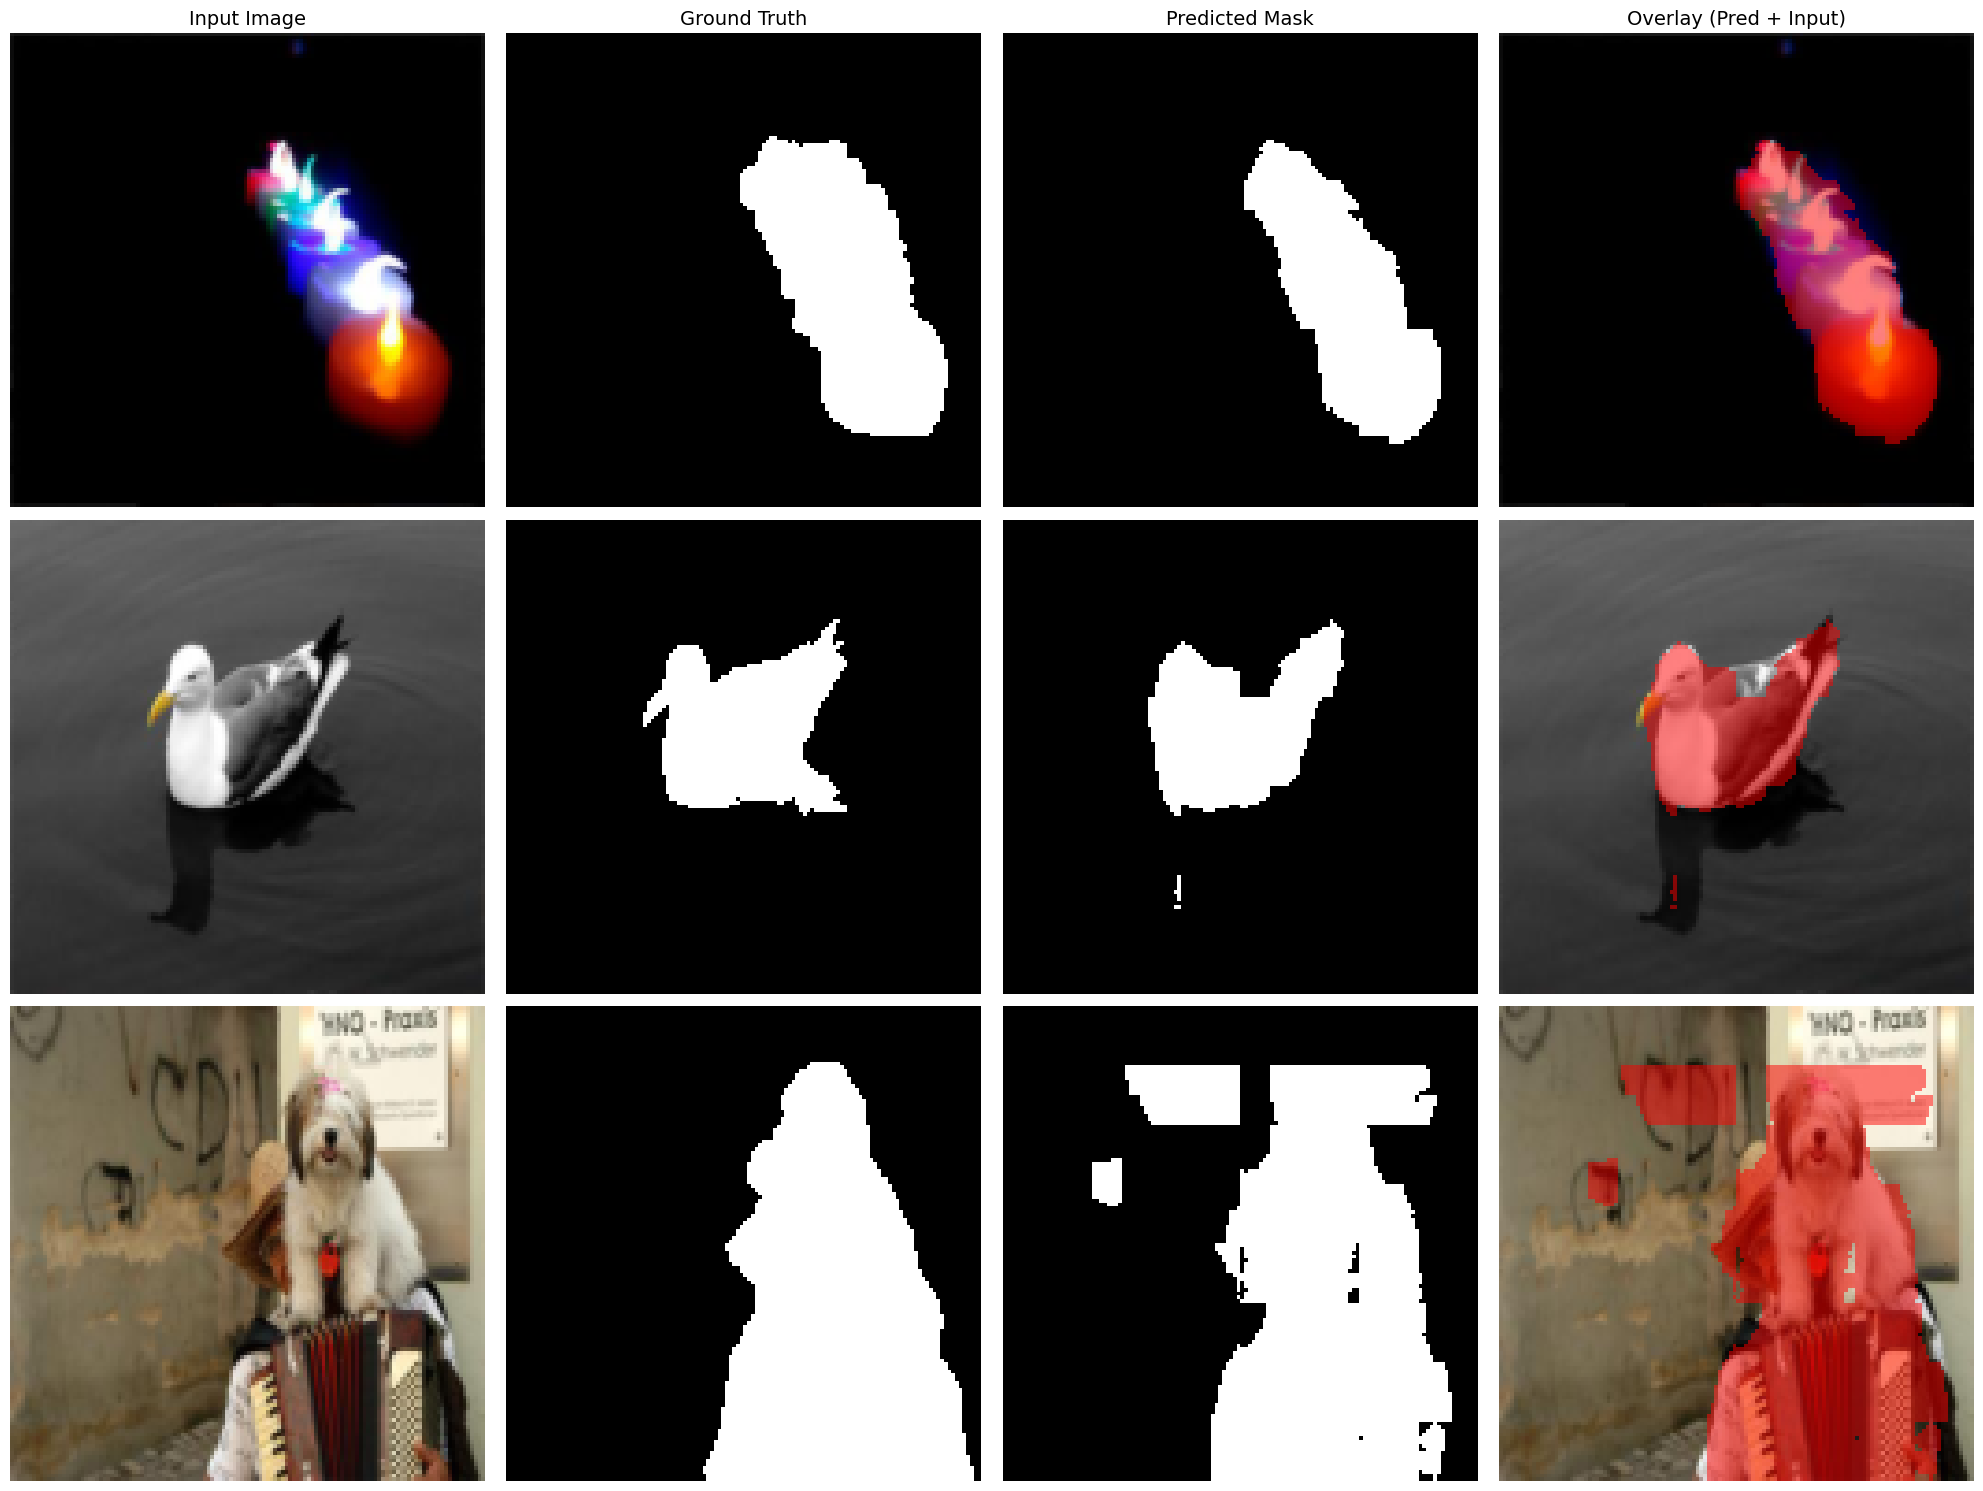

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Ensure the model is in evaluation mode before predicting
model.eval()

# 1. Grab a single batch of unseen data from the test loader
imgs, masks = next(iter(test_loader))
imgs_device = imgs.to(device)

# 2. Run Inference
with torch.no_grad():
    preds = model(imgs_device).cpu() # Move predictions back to CPU for plotting

# Set up the plot for 3 sample images
num_samples = 3
plt.figure(figsize=(20, 5 * num_samples))

for i in range(num_samples):
    # Format the image for matplotlib: Convert from (Channels, Height, Width) to (Height, Width, Channels)
    img_np = imgs[i].permute(1, 2, 0).numpy()
    
    # Depending on your normalization, ensure image pixels are bound between 0 and 1
    img_np = np.clip(img_np, 0, 1) 
    
    # Squeeze masks to 2D (Height, Width) for grayscale plotting
    gt_mask = masks[i].squeeze().numpy()
    pred_mask = preds[i].squeeze().numpy()
    
    # Threshold the model's raw probabilities into a strict binary mask
    pred_bin = (pred_mask > 0.5).astype(np.float32)

    # ==========================================
    # [REQUIREMENT]: Input image
    # ==========================================
    plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(img_np)
    plt.title("Input Image" if i == 0 else "", fontsize=14)
    plt.axis('off')

    # ==========================================
    # [REQUIREMENT]: Ground-truth saliency mask
    # ==========================================
    plt.subplot(num_samples, 4, i * 4 + 2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title("Ground Truth" if i == 0 else "", fontsize=14)
    plt.axis('off')

    # ==========================================
    # [REQUIREMENT]: Predicted saliency mask
    # ==========================================
    plt.subplot(num_samples, 4, i * 4 + 3)
    plt.imshow(pred_bin, cmap='gray')
    plt.title("Predicted Mask" if i == 0 else "", fontsize=14)
    plt.axis('off')

    # ==========================================
    # [REQUIREMENT]: Overlay (predicted + input)
    # ==========================================
    plt.subplot(num_samples, 4, i * 4 + 4)
    plt.imshow(img_np) # Plot the base image first
    
    # Create a transparency mask: Hide the '0' values, only show the '1' values
    masked_pred = np.ma.masked_where(pred_bin == 0, pred_bin)
    
    # Overlay the predicted mask in a bright color (autumn/red) with 50% transparency
    plt.imshow(masked_pred, cmap='autumn', alpha=0.5, interpolation='none')
    plt.title("Overlay (Pred + Input)" if i == 0 else "", fontsize=14)
    plt.axis('off')

# Display the final composite grid
plt.tight_layout()
plt.show()

In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==========================================
# EXPERIMENT: THE UPGRADED ARCHITECTURE
# ==========================================
class SaliencyImproved(nn.Module):
    def __init__(self):
        super(SaliencyImproved, self).__init__()
        
        # [MODIFICATION 1]: Adding Batch Normalization to every convolutional block
        self.enc1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2) 
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2) 
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.pool3 = nn.MaxPool2d(2) 
        
        # [MODIFICATION 2]: Adding Dropout (0.5) to the bottleneck to prevent overfitting
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), 
            nn.BatchNorm2d(256), 
            nn.ReLU(),
            nn.Dropout(0.5) 
        )

        # Decoder (Using Skip Connections for sharper edges)
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU()) 
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU()) 
        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU()) 
        self.final_conv = nn.Sequential(nn.Conv2d(32, 1, kernel_size=1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        
        d1 = self.up1(e4)                          
        d1 = self.dec1(torch.cat([d1, e3], dim=1)) 
        d2 = self.up2(d1)                          
        d2 = self.dec2(torch.cat([d2, e2], dim=1)) 
        d3 = self.up3(d2)                          
        d3 = self.dec3(torch.cat([d3, e1], dim=1)) 
        return self.final_conv(d3)

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
improved_model = SaliencyImproved().to(device)
optimizer = optim.Adam(improved_model.parameters(), lr=1e-3)

# [MODIFICATION 3]: Learning Rate Scheduler (Drops LR if validation loss plateaus)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

# Training Setup
epochs = 25
best_val_loss = float('inf')
patience = 4 # Increased slightly to allow the scheduler time to work
no_improvement_count = 0
improved_model_path = 'improved_model.pth'

print("🚀 Starting Improved Training with BatchNorm, Dropout, and LR Scheduler...")

for epoch in range(epochs):
    improved_model.train()
    total_train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = hybrid_loss(improved_model(imgs), masks)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    improved_model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            total_val_loss += hybrid_loss(improved_model(imgs), masks).item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {avg_val_loss:.4f}")

    # Step the scheduler based on validation loss
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(improved_model.state_dict(), improved_model_path)
        no_improvement_count = 0
    else:
        no_improvement_count += 1
        
    if (epoch + 1) >= 15 and no_improvement_count >= patience:
        print(f"🛑 Early stopping triggered at epoch {epoch+1}.")
        break

print("\n🎉 Improved Training Complete!")

C:\Users\Admin\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


🚀 Starting Improved Training with BatchNorm, Dropout, and LR Scheduler...
Epoch [01/25] | Train Loss: 0.6301 | Val Loss: 0.5562
Epoch [02/25] | Train Loss: 0.5285 | Val Loss: 0.5187
Epoch [03/25] | Train Loss: 0.4932 | Val Loss: 0.4992
Epoch [04/25] | Train Loss: 0.4717 | Val Loss: 0.4544
Epoch [05/25] | Train Loss: 0.4539 | Val Loss: 0.4396
Epoch [06/25] | Train Loss: 0.4415 | Val Loss: 0.4229
Epoch [07/25] | Train Loss: 0.4322 | Val Loss: 0.4317
Epoch [08/25] | Train Loss: 0.4218 | Val Loss: 0.4244
Epoch [09/25] | Train Loss: 0.4149 | Val Loss: 0.4195
Epoch [10/25] | Train Loss: 0.4106 | Val Loss: 0.4020
Epoch [11/25] | Train Loss: 0.4019 | Val Loss: 0.3975
Epoch [12/25] | Train Loss: 0.3991 | Val Loss: 0.4348
Epoch [13/25] | Train Loss: 0.3956 | Val Loss: 0.4019
Epoch [14/25] | Train Loss: 0.3913 | Val Loss: 0.3861
Epoch [15/25] | Train Loss: 0.3869 | Val Loss: 0.3905
Epoch [16/25] | Train Loss: 0.3822 | Val Loss: 0.3930
Epoch [17/25] | Train Loss: 0.3796 | Val Loss: 0.3800
Epoch [1

📊 Evaluating Improved Model...

🏆 FINAL MODEL COMPARISON TABLE
| Metric          |   Baseline CNN |   Improved U-Net |
|:----------------|---------------:|-----------------:|
| Mean IoU (mIoU) |         0.5852 |            0.672 |
| F1-Score        |         0.7374 |            0.803 |



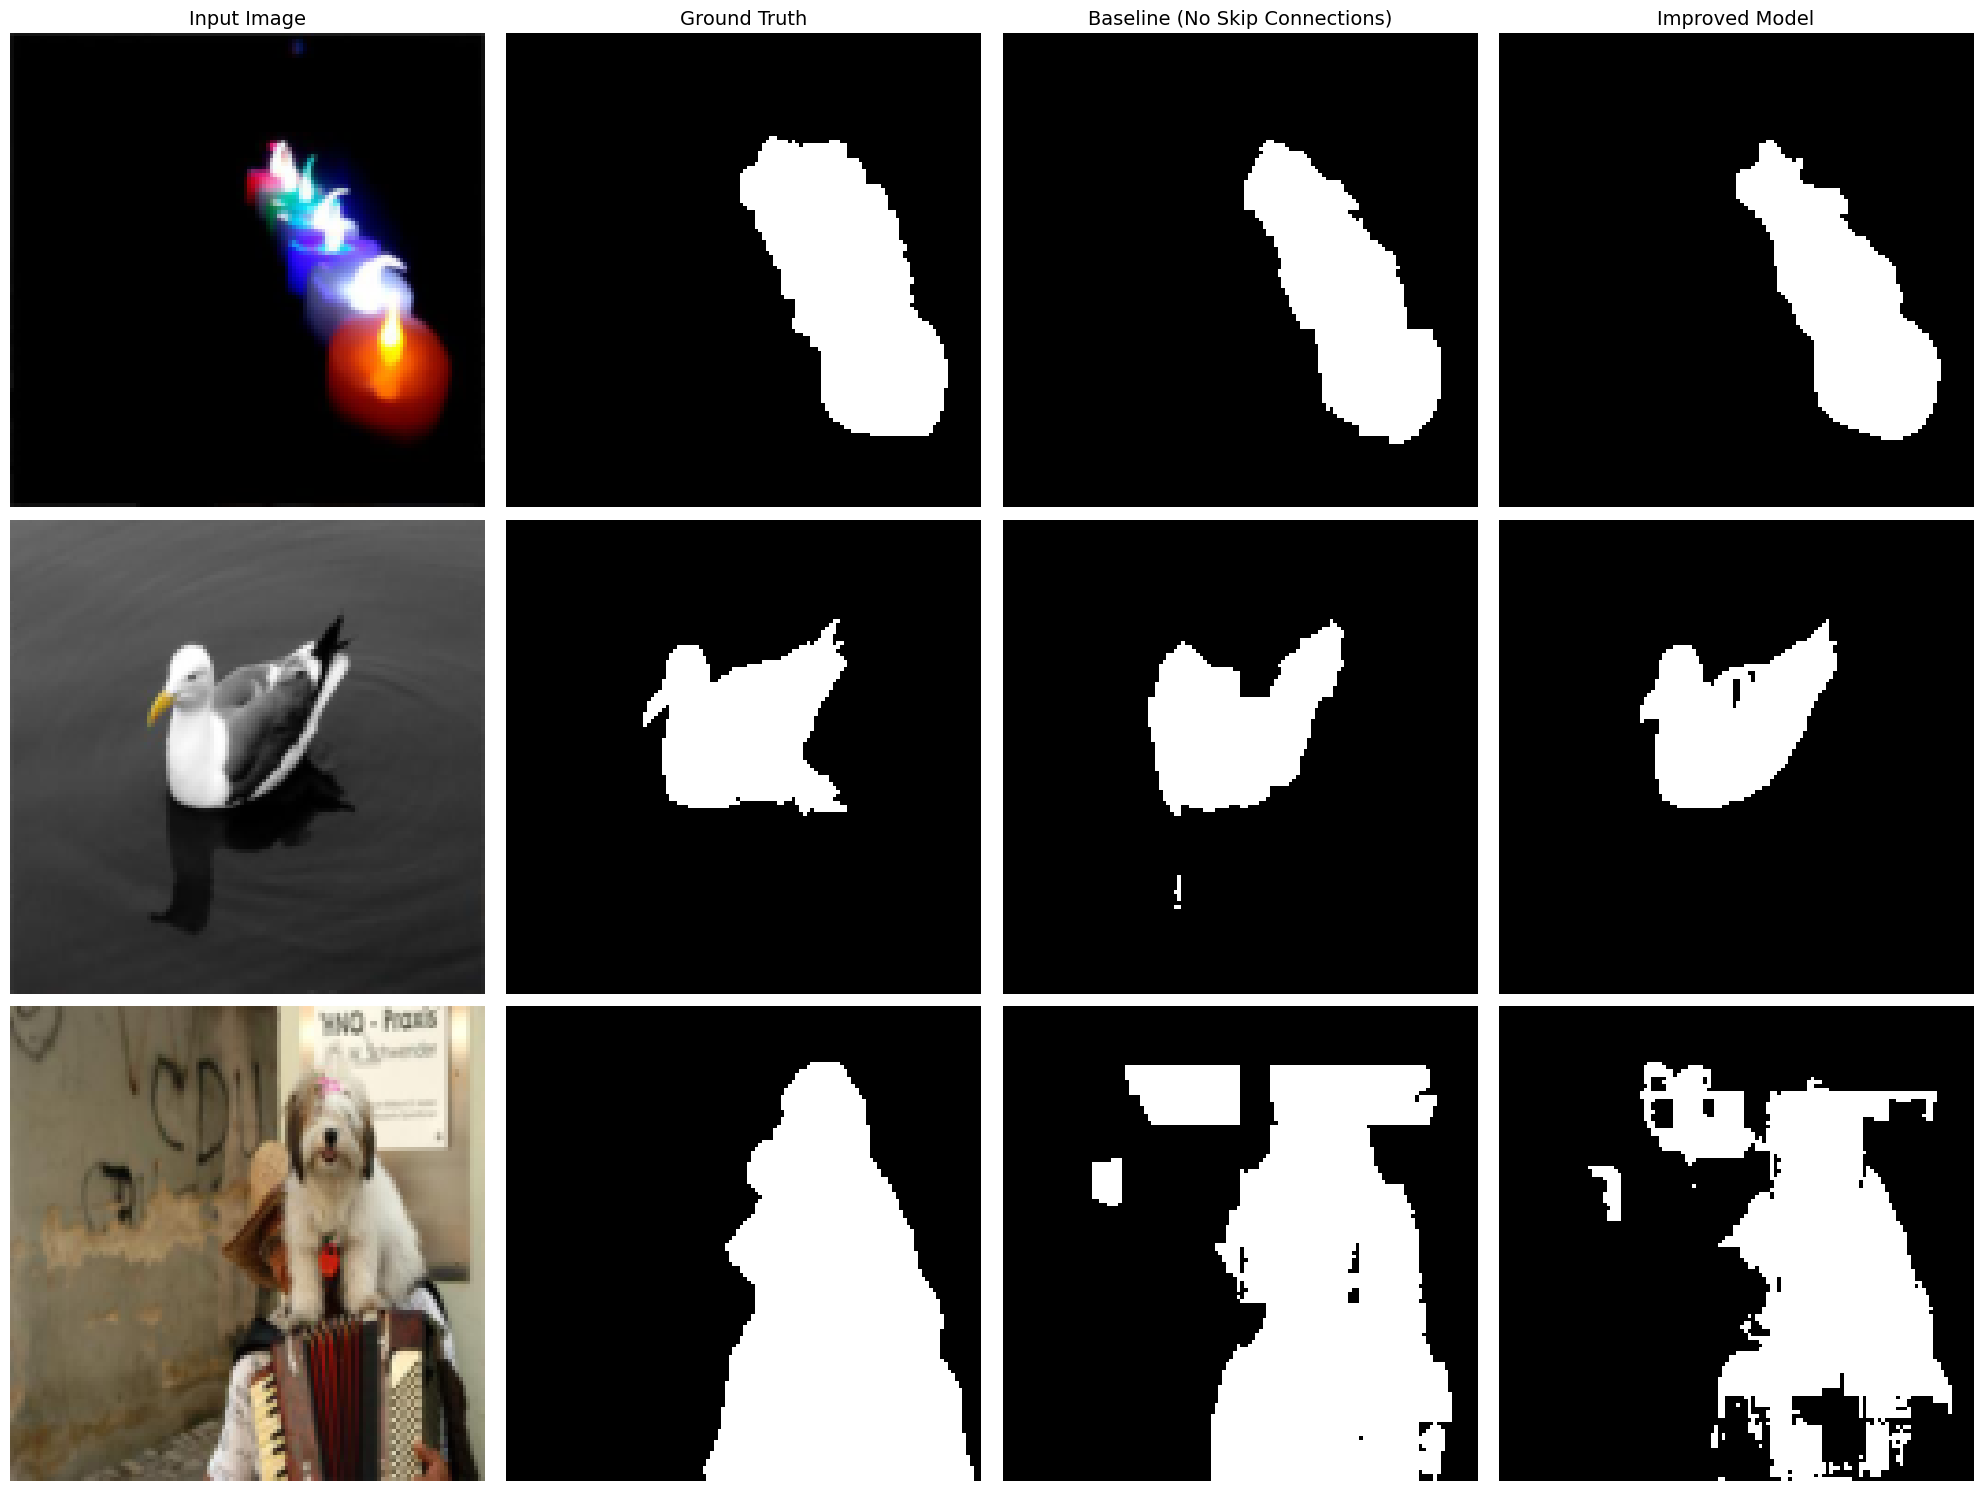

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# ==========================================
# 1. EVALUATE THE IMPROVED MODEL
# ==========================================
improved_model.load_state_dict(torch.load('improved_model.pth'))
improved_model.eval()

total_iou, total_f1 = 0.0, 0.0

print("📊 Evaluating Improved Model...")
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds_bin = (improved_model(imgs) > 0.5).float().view(-1)
        masks_flat = masks.view(-1)
        
        TP = (preds_bin * masks_flat).sum().item()
        FP = (preds_bin * (1 - masks_flat)).sum().item()
        FN = ((1 - preds_bin) * masks_flat).sum().item()
        
        precision = (TP + 1e-6) / (TP + FP + 1e-6)
        recall = (TP + 1e-6) / (TP + FN + 1e-6)
        
        total_iou += (TP + 1e-6) / (TP + FP + FN + 1e-6)
        total_f1 += 2 * (precision * recall) / (precision + recall + 1e-6)

num_batches = len(test_loader)
imp_iou = total_iou / num_batches
imp_f1 = total_f1 / num_batches

# 2. GENERATE COMPARISON TABLE

# We use your previous baseline results here
comparison_data = {
    "Metric": ["Mean IoU (mIoU)", "F1-Score"],
    "Baseline CNN": ["0.5852", "0.7374"],
    "Improved U-Net": [f"{imp_iou:.4f}", f"{imp_f1:.4f}"]
}
df_compare = pd.DataFrame(comparison_data)
print("\n" + "="*50)
print("🏆 FINAL MODEL COMPARISON TABLE")
print("="*50)
print(df_compare.to_markdown(index=False))
print("="*50 + "\n")

# 3. SIDE-BY-SIDE VISUAL COMPARISON

# Load the baseline model to compare
baseline_model = SaliencyBaseline().to(device)
baseline_model.load_state_dict(torch.load('best_model.pth'))
baseline_model.eval()

# Grab a batch from the test set
imgs, masks = next(iter(test_loader))
imgs_device = imgs.to(device)

with torch.no_grad():
    base_preds = baseline_model(imgs_device).cpu()
    imp_preds = improved_model(imgs_device).cpu()

# Set up the plot
num_samples = 3
plt.figure(figsize=(20, 5 * num_samples))

for i in range(num_samples):
    # Format images and masks for plotting
    img_np = np.clip(imgs[i].permute(1, 2, 0).numpy(), 0, 1)
    gt_mask = masks[i].squeeze().numpy()
    base_bin = (base_preds[i].squeeze().numpy() > 0.5).astype(np.float32)
    imp_bin = (imp_preds[i].squeeze().numpy() > 0.5).astype(np.float32)

    # 1. Input Image
    plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(img_np)
    plt.title("Input Image" if i == 0 else "", fontsize=14)
    plt.axis('off')

    # 2. Ground Truth Mask
    plt.subplot(num_samples, 4, i * 4 + 2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title("Ground Truth" if i == 0 else "", fontsize=14)
    plt.axis('off')

    # 3. Baseline Prediction
    plt.subplot(num_samples, 4, i * 4 + 3)
    plt.imshow(base_bin, cmap='gray')
    plt.title("Baseline (No Skip Connections)" if i == 0 else "", fontsize=14)
    plt.axis('off')

    # 4. Improved Prediction
    plt.subplot(num_samples, 4, i * 4 + 4)
    plt.imshow(imp_bin, cmap='gray')
    plt.title("Improved Model" if i == 0 else "", fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# OpenCV REAL-WORLD INFERENCE

print("📷 Running OpenCV Inference Pipeline...")

# 1. Load your improved model to ensure we are using the best weights
# Make sure SaliencyImproved is defined in memory!
final_model = SaliencyImproved().to(device)
final_model.load_state_dict(torch.load('improved_model.pth'))
final_model.eval()

# 2. Provide the path to ANY custom test image on your computer
# Download a picture of a dog, car, or person and put it in your project folder
image_path = 'my_custom_test_image.jpg' # <-- CHANGE THIS to your image file!

# [OPENCV REQUIREMENT]: Read the image from the hard drive
original_img = cv2.imread(image_path)

if original_img is None:
    print(f"⚠️ Could not load image at '{image_path}'. Please check the file path.")
else:
    # [OPENCV REQUIREMENT]: Convert color space (BGR to RGB for PyTorch and Matplotlib)
    img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    # [OPENCV REQUIREMENT]: Resize image to match our model's expected input (128x128)
    img_resized = cv2.resize(img_rgb, (128, 128))
    
    # Format for PyTorch (Channels, Height, Width) and normalize (0 to 1)
    img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(device) 
    
    # Run Inference
    with torch.no_grad():
        pred = final_model(img_tensor)
        
    # Format the output mask back to an OpenCV-friendly format (0 to 255 integer)
    mask_np = pred.squeeze().cpu().numpy()
    mask_bin = (mask_np > 0.5).astype(np.uint8) * 255
    
    # [OPENCV REQUIREMENT]: Create a colored heatmap for the overlay
    # We create a blank Red image, then apply our predicted mask to it
    heatmap = np.zeros_like(img_resized)
    heatmap[:, :, 0] = mask_bin # Set the Red channel to our mask's shape
    
    # [OPENCV REQUIREMENT]: Blend the original image and the heatmap together
    overlay = cv2.addWeighted(img_resized, 0.7, heatmap, 0.5, 0)
    
    # [OPENCV REQUIREMENT]: Save the final output to your hard drive
    # We must convert back to BGR because cv2.imwrite expects BGR formatting!
    final_output_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    cv2.imwrite('opencv_final_output.jpg', final_output_bgr)
    print("✅ Successfully processed and saved 'opencv_final_output.jpg'!")
    
    # Display the final result using Matplotlib
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title("OpenCV Input Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("OpenCV Mask Overlay")
    plt.axis('off')
    plt.show()

📷 Running OpenCV Inference Pipeline...
⚠️ Could not load image at 'my_custom_test_image.jpg'. Please check the file path.


In [16]:
pip install gradio

   ---------------------------------------- 0.0/19.7 MB ? eta -:--:--
    --------------------------------------- 0.3/19.7 MB ? eta -:--:--
   -- ------------------------------------- 1.0/19.7 MB 2.6 MB/s eta 0:00:08
   --- ------------------------------------ 1.8/19.7 MB 3.0 MB/s eta 0:00:06
   ---- ----------------------------------- 2.1/19.7 MB 3.0 MB/s eta 0:00:06
   ----- ---------------------------------- 2.9/19.7 MB 2.8 MB/s eta 0:00:07
   ------- -------------------------------- 3.7/19.7 MB 2.9 MB/s eta 0:00:06
   --------- ------------------------------ 4.7/19.7 MB 3.2 MB/s eta 0:00:05
   ----------- ---------------------------- 5.5/19.7 MB 3.3 MB/s eta 0:00:05
   ------------- -------------------------- 6.8/19.7 MB 3.6 MB/s eta 0:00:04
   --------------- ------------------------ 7.9/19.7 MB 3.8 MB/s eta 0:00:04
   ------------------ --------------------- 9.2/19.7 MB 4.0 MB/s eta 0:00:03
   --------------------- ------------------ 10.7/19.7 MB 4.3 MB/s eta 0:00:03
   ---------

In [18]:
import gradio as gr
import cv2
import torch
import numpy as np
import time

print("🚀 Launching Upgraded Gradio Web UI with Inference Timer...")

# 1. Ensuring the final model is loaded in memory
final_model = SaliencyImproved().to(device)
final_model.load_state_dict(torch.load('improved_model.pth'))
final_model.eval()

# 2. Defining the core prediction function
def predict_saliency(input_image):
    # [NEW]: Start the inference timer!
    start_time = time.time()
    
    # Preprocessing the image
    img_resized = cv2.resize(input_image, (128, 128))
    img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    # Running the model
    with torch.no_grad():
        pred = final_model(img_tensor)
        
    # Stopping the timer immediately after the model finishes!
    end_time = time.time()
    
    # Calculateing total time in milliseconds
    inference_time_ms = (end_time - start_time) * 1000
    time_string = f"{inference_time_ms:.2f} ms"
        
    # Post-process predictions for display
    mask_np = pred.squeeze().cpu().numpy()
    mask_bin = (mask_np > 0.5).astype(np.uint8) * 255
    
    # Creating the OpenCV Overlay
    heatmap = np.zeros_like(img_resized)
    heatmap[:, :, 0] = mask_bin 
    overlay = cv2.addWeighted(img_resized, 0.7, heatmap, 0.5, 0)
    
    # Formatting mask for Gradio (1-channel to 3-channel RGB)
    mask_display = cv2.cvtColor(mask_bin, cv2.COLOR_GRAY2RGB)
    
    # [REQUIREMENT CHECK]: Return all 4 requested elements
    return img_resized, mask_display, overlay, time_string

# 3. Building the User Interface
demo = gr.Interface(
    fn=predict_saliency,
    inputs=gr.Image(label="Upload any Image"),
    # [REQUIREMENT CHECK]: Display all 4 outputs clearly
    outputs=[
        gr.Image(label="1. Input Image (128x128)"),
        gr.Image(label="2. Output Saliency Mask"),
        gr.Image(label="3. Overlayed Visualization"),
        gr.Textbox(label="4. Inference Time per Image")
    ],
    title="Subject Saliency Detector (Genpact Demo)",
    description="Upload an image to see the U-Net extract the subject and calculate real-time inference speed.",
    theme="default"
)

# 4. Launch the app
demo.launch(share=False)

🚀 Launching Upgraded Gradio Web UI with Inference Timer...


C:\Users\Admin\anaconda3\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
